# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [23]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from scipy.stats import chi2_contingency


### Cargar Dataset

In [4]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [8]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


 Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- nivel_ingreso
- visitas_mes
- compras_mes
- gasto_publicidad_dirigida
- satisfaccion
- ingreso_anual

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna edad necesita ser cambiada


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [9]:
# Corregir el tipo de dato
df['edad']=df['edad'].astype(int)

In [10]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [21]:
# Estadísticas descriptivas de variables numéricas
variables_numericas=['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'ingreso_anual', 'satisfaccion']
df[variables_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,ingreso_anual,satisfaccion
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,36.594180,3.603693
std,11.492378,9833.166305,3.158189,1.105284,10.880724,34.484888,0.685300
min,18.000000,8000.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,0.000000,3.100000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,30.705000,3.600000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,58.220000,4.100000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,244.690000,5.000000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

- `edad` Promedio: 38 años → población adulta.
Rango amplio (18–75) → buena diversidad

Nivel de ingreso:
Promedio: 30K → ingresos medios.
Alta variabilidad → hay segmentos diferenciados.
Rango amplio (8K–74K) → posible segmentación por poder adquisitivo.

Visitas al mes:
Promedio: 10 visitas → engagement moderado.
Máximo 25 → existen usuarios muy activos.
Distribución bastante centrada 

Compras al mes:
Promedio: 1.2 → baja conversión vs visitas.
25% no compra  → oportunidad de mejora.
Máximo 8 → pocos clientes muy compradores.

Gasto en publicidad dirigida:
Promedio: 20 → inversión moderada.
Rango amplio (0–75) → algunos usuarios no reciben publicidad.

Ingreso anual:
Mediana: 30 → pero Q1=0 
Muchos usuarios con ingreso 0 → posible dato faltante o segmento sin ingresos.
Alta dispersión → distribución sesgada.

🔹 Satisfacción

Promedio: 3.6/5 → aceptable pero mejorable.
Baja variabilidad → percepciones similares entre usuarios.
No hay extremos fuertes → experiencia relativamente estable.

#### Explorar variables binarias

In [25]:
# Verificar que cada columna tenga únicamente dos valores posibles
variables_binarias= ['miembro_premium', 'abandono']
for variable in variables_binarias:
    print(f"{variable}: {df[variable].unique()}")

miembro_premium: [0 1]
abandono: [0 1]


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` tiene solo dos valores unicos [0, 1]
- `abandono` —  tiene solo dos valores unicos [0, 1]

#### Explorar variables categóricas

In [26]:
# Verificar el número de valores únicos por variable categórica
variables_categoricas= ['id_cliente', 'tipo_dispositivo', 'region']
for variable in variables_categoricas:
    print(f"{variable}: {df[variable].unique()}")

id_cliente: ['CL-100000' 'CL-100001' 'CL-100002' ... 'CL-114997' 'CL-114998'
 'CL-114999']
tipo_dispositivo: ['móvil' 'tablet' 'escritorio']
region: ['norte' 'sur' 'este' 'oeste']


In [27]:
# Explorar variables categóricas y cómo se distribuyen
for variable in variables_categoricas:
    print(f"{variable}: {df[variable].value_counts()}")

id_cliente: CL-109723    1
CL-110995    1
CL-111097    1
CL-108282    1
CL-105141    1
            ..
CL-102471    1
CL-100407    1
CL-106283    1
CL-113439    1
CL-109489    1
Name: id_cliente, Length: 15000, dtype: int64
tipo_dispositivo: móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64
region: norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` — móvil domina (9818), seguido de escritorio y tablet. Alta concentración en móvil. tablet esta muy por debajo de movil 
-  region - distribucion relativamente equilibrada, no hay una región extremadamente dominante, domina region Norte
-  id_client - Todos los valores tienen frecuencia 1 (15000 únicos).

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

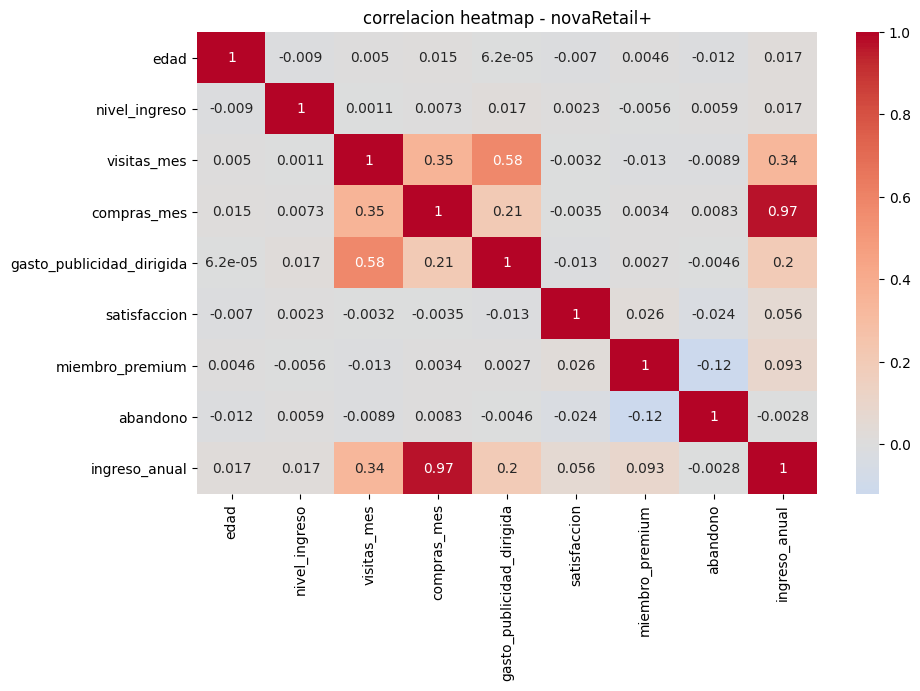

In [32]:
# Visualizar la matriz de correlación para identificar relaciones

corr=df.corr()
plt.figure(figsize= (10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('correlacion heatmap - novaRetail+')
plt.savefig('heatmap_novaRetail.png', dpi=300, bbox_inches='tight')
plt.show()


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
Se observa que compras_mes ↔ ingreso_anual (0.97) tiene una relación muy fuerte a más compras, mayor ingreso anual, prácticamente se mueven juntos (casi lineal).

visitas_mes ↔ gasto_publicidad_dirigida (0.58)
Relación moderada-alta
Más publicidad → más visitas.

edad, nivel_ingreso, satisfaccion con casi todas las variables correlaciones cercanas a 0
No están influyendo significativamente en comportamiento.
abandono con todo
No muestra relaciones claras.

visitas_mes → compras_mes → ingreso_anual
Forman una cadena lógica
más visitas
más compras
más ingresos

Observaciones respecto a `ingreso_anual`  
- Presenta una relacion muy fuerte con compras_mes, parece ser una variable derivada de las compras. parece que el ingreso depende directamente del número de compras.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - decido no incluir un scatterplot general ya que seria muy consufo a demas de hacerle perder el foco a lo que realmente aporta al analisis, asi que lo mejor en este caso es hacerlo en pares para visualizar relaciones importantes para el negocio.

### Scatterplot para pares clave

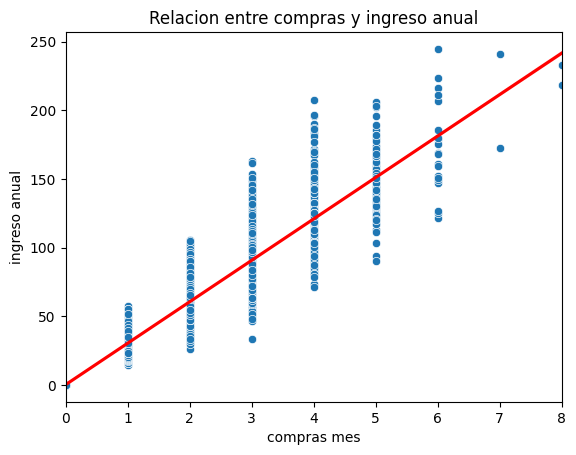

In [31]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.scatterplot(data=df, x="compras_mes", y="ingreso_anual")
sns.regplot(data=df, x="compras_mes", y="ingreso_anual", scatter=False, color='red' )
plt.title('Relacion entre compras y ingreso anual')
plt.xlabel('compras mes')
plt.ylabel('ingreso anual')
plt.show()

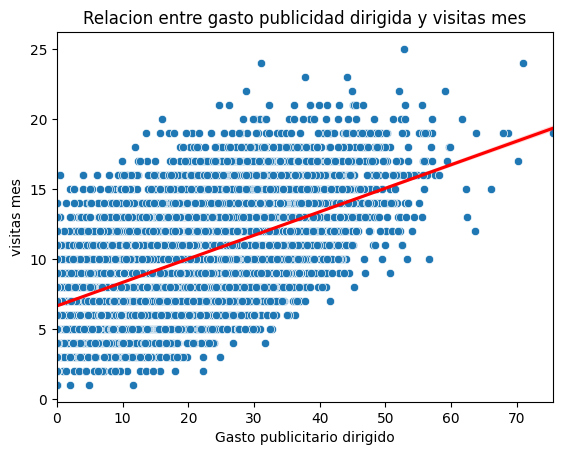

In [34]:
sns.scatterplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes")
sns.regplot(data=df, x="gasto_publicidad_dirigida", y="visitas_mes", scatter=False, color='red' )
plt.title('Relacion entre gasto publicidad dirigida y visitas mes')
plt.xlabel('Gasto publicitario dirigido')
plt.ylabel('visitas mes')
plt.show()

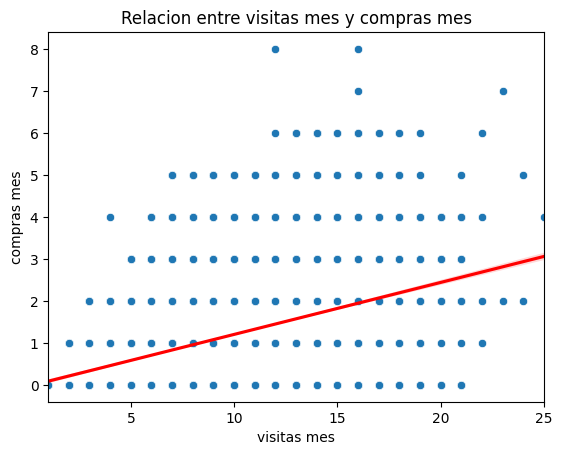

In [35]:
sns.scatterplot(data=df, x="visitas_mes", y="compras_mes")
sns.regplot(data=df, x="visitas_mes", y="compras_mes", scatter=False, color='red' )
plt.title('Relacion entre visitas mes y compras mes')
plt.xlabel('visitas mes')
plt.ylabel('compras mes')
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**compras vs ingreso anual**
- Dirección positiva
- dispersion media a baja
- poca presencia de outliers no son extremos
- colinealidad alta, relacion casi perfecta

** gasto_publicidad_dirigida vs visitas_mes **
- Dirección positiva, tendencia clara y consistente
- Dispercion media-alta, variacion en visitas ara un mismo nivel de gasto
- outlier existentes pero muy leves
- Colinealidad moderada

** visits_mes vs compras_mes **
- Direccion positiva
- Dispercion alta 
- Outliers existentes algunos
- Colinealidad baja-moderada

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [8]:


pares_importantes = [
    ('compras_mes', 'ingreso_anual'),
    ('gasto_publicidad_dirigida', 'visitas_mes'),
    ('visitas_mes', 'compras_mes')

]


# Calcular ambos métodos para todos los pares
for var1, var2 in pares_importantes:
    pearson = df[var1].corr(df[var2], method='pearson')
    spearman = df[var1].corr(df[var2], method='spearman')
    
    print(f"{var1} vs {var2}:")
    print(f"  Pearson:  {pearson:.4f}")
    print(f"  Spearman: {spearman:.4f}")
    print()



compras_mes vs ingreso_anual:
  Pearson:  0.9671
  Spearman: 0.9675

gasto_publicidad_dirigida vs visitas_mes:
  Pearson:  0.5789
  Spearman: 0.5593

visitas_mes vs compras_mes:
  Pearson:  0.3538
  Spearman: 0.3329



✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**compras_mes vs ingreso_anual**
- Correlación lineal y consistente, casi perfecta, a mas compras mas ingresos
- direccion positiva

**gasto_publicidad_dirigida vs visitas_mes**
- Correlación moderada pero consistente, mas gastos se asocia con visitas pero no es perfecta
- direccion positiva

**visitas_mes vs compras_mes**
- relacion debil, hay mucha vcariabilidad
- baja colinealidad
- diredcion positiva

### Punto-biserial

In [16]:
# Calcular correlación entre variables relevantes
pointbiserialr(df['abandono'], df['ingreso_anual'])


SignificanceResult(statistic=-0.002823934021617148, pvalue=0.7294691719078393)

In [17]:
pointbiserialr(df['miembro_premium'], df['ingreso_anual'])

SignificanceResult(statistic=0.0930994396198015, pvalue=3.0943076155242597e-30)

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**abandono vs ingreso anual**
- Relacion negativa, magnitud baja

**miembro premium vs ingreso anual **
- Relación debil, direccion positiva

  abandono y miembro premium no afectan al ingreso anual

### V de Cramér

In [31]:
# Función para calcular V de Cramér

tabla= pd.crosstab(df['region'], df['tipo_dispositivo'])
chi2, p, dof, expected = chi2_contingency(tabla)
n= tabla.sum().sum()
cramers_v=np.sqrt(chi2 / (n*(min(tabla.shape)-1)))
cramers_v

0.012378338407739397

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér
relacion inexistente, no hay un patrón geográfico relevante, Usuarios de distintas regiones usan dispositivos de forma muy similar.


## Sección 5 - Interpretación de resultados para el negocio


### Hallazgo 1 — 

**Evidencia visual:**   

<img src="heatmap_novaRetail.png" width="400">

**Evidencia numérica:** compras_mes ↔ ingreso_anual (0.97) 

**Interpretación**  tienen una relación muy fuerte; parece que a más compras mayor ingreso anual, prácticamente se mueven juntos (casi lineal).

**No podemos afirmar**  causalidad, pueden existir variables ocultas o relaciones indirectas.

**Implicación de negocio**  
se puede crear estrategias diferenciadas (no tratar a todos igual)
se puede enfocar campañas en clientes de alto ingreso para maximizar ROI
diseñar campañas específicas para aumentar compras en ingresos bajo


### Hallazgo 2 — 

**Evidencia visual:**  
<img src="heatmap_novaRetail.png" width="400">

**Evidencia numérica:** visitas_mes ↔ gasto_publicidad_dirigida (0.58)

**Interpretación** 
Magnitud moderada–alta → hay relación clara, pero no es determinante.

**No podemos afirmar** 
No podemos afirmar causalidad directa, que la publicidad explica la mayoría del tráfico 
No podemos afirmar linealidad perfecta

**Implicación de negocio** 
oportunidad de mejora en el marketing
variedad depublicidad, no depender solo de paid media
marketing multicanal


## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- No mide calidad del tráfico
- Posible causalidad inversa
- posible Colinealidad
- Posible dependencia entre variables

### **Próximos pasos** 

Probar segmentación adicional
- segmentar compras e ingresos
investigar de donde viene el trafico, a que segmento pertenece el trafico

